In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plot
import seaborn as seaborn
import folium as google_maps
from matplotlib import colors

In [3]:
print("1.Feladat")
try:
    data = pd.read_csv("data.csv")
    print("Load succes")

    
    print("Check:")
    print(data.head())
except Exception as e:
    print(f"Load fail:\n{e}")



1.Feladat
Load succes
Check:
   Geographical Location (Latitude)  Geographical Location (Longitude)  \
0                         42.867278                        -107.997678   
1                         34.337029                        -104.681197   
2                         34.831615                         -93.134004   
3                         45.463162                        -120.709056   
4                         41.444474                         -99.464055   

  State of Sewage System Sampling Date  Nitrogen (mg/L)  Phosphorus (mg/L)  \
0               Moderate    2015-09-30         5.447159           4.634808   
1                   Good    2020-01-29         9.087964           3.129082   
2               Moderate    2017-09-09         0.485658           4.545678   
3                   Poor    2019-11-12         2.666448           4.090627   
4               Moderate    2016-08-19         8.425540           1.247981   

   Population  
0      923253  
1     1196631  
2      78

In [4]:
print("2. Fealadat")
data.info()

2. Fealadat
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Geographical Location (Latitude)   412 non-null    float64
 1   Geographical Location (Longitude)  412 non-null    float64
 2   State of Sewage System             412 non-null    object 
 3   Sampling Date                      412 non-null    object 
 4   Nitrogen (mg/L)                    412 non-null    float64
 5   Phosphorus (mg/L)                  412 non-null    float64
 6   Population                         412 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 22.7+ KB


In [5]:
print("3. feladat")
try:
    data["Sampling Date"] = pd.to_datetime(data["Sampling Date"])
except Exception as e:
    print(e)

try:
    missing = data.isnull().sum()
    if(missing.any()):
        print(f"Hiányzó adatok:\n{missing}")
    else:
        print("Nincsenek hiányzó adatok.")
except Exception as e:
    print(e)


3. feladat
Nincsenek hiányzó adatok.


4. feladat A,


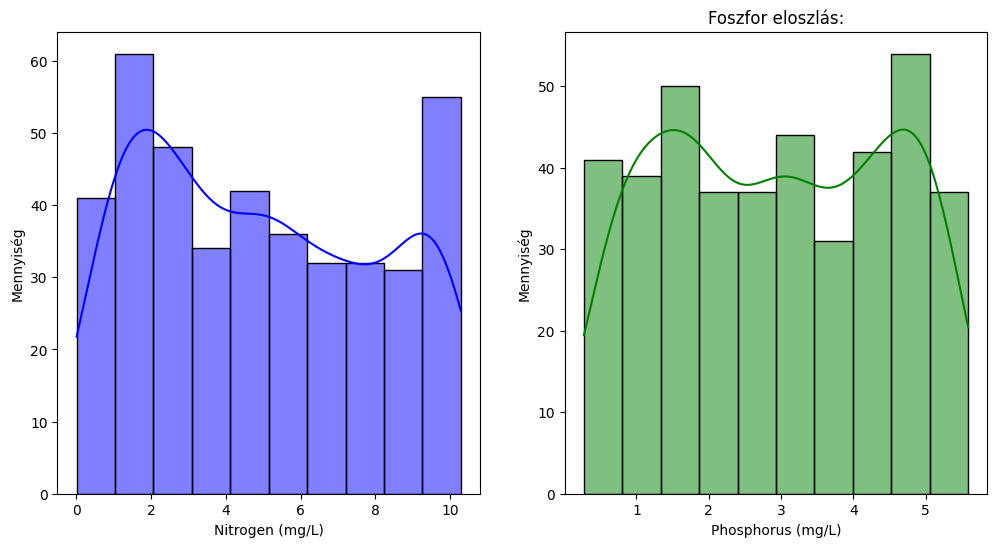

In [6]:
print("4. feladat A,")
plot.figure(figsize=(12,6))

plot.subplot(1, 2, 1) #sor oszlop hely
#Nitorgen
seaborn.histplot(
    data["Nitrogen (mg/L)"], 
    kde ="true", 
    color="blue", 
    edgecolor="black", 
    bins=10)
#plot.title("Nitrogén eloszlás:")
plot.xlabel("Nitrogen (mg/L)")
plot.ylabel("Mennyiség")
#Foszfor
plot.subplot(1, 2, 2)
seaborn.histplot(
    data["Phosphorus (mg/L)"], 
    kde="true", 
    color="green", 
    edgecolor="black", 
    bins=10)
plot.ylabel("Mennyiség")
plot.title("Foszfor eloszlás:")
plot.xlabel("Phosphorus (mg/L)")

plot.show()

4. feladat B,


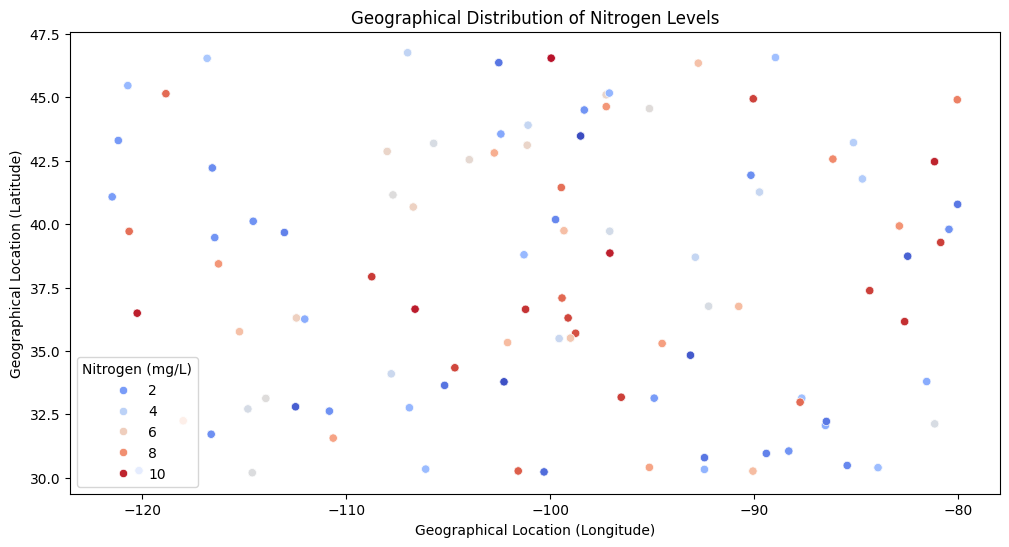

In [7]:
print("4. feladat B,")
plot.figure(figsize=(12,6))
seaborn.scatterplot(
    data,
    x="Geographical Location (Longitude)",
    y="Geographical Location (Latitude)",
    hue="Nitrogen (mg/L)",
    palette="coolwarm",
    )
plot.title("Geographical Distribution of Nitrogen Levels")
plot.legend(loc="lower left", title="Nitrogen (mg/L)")
plot.show()

4. feladat C,


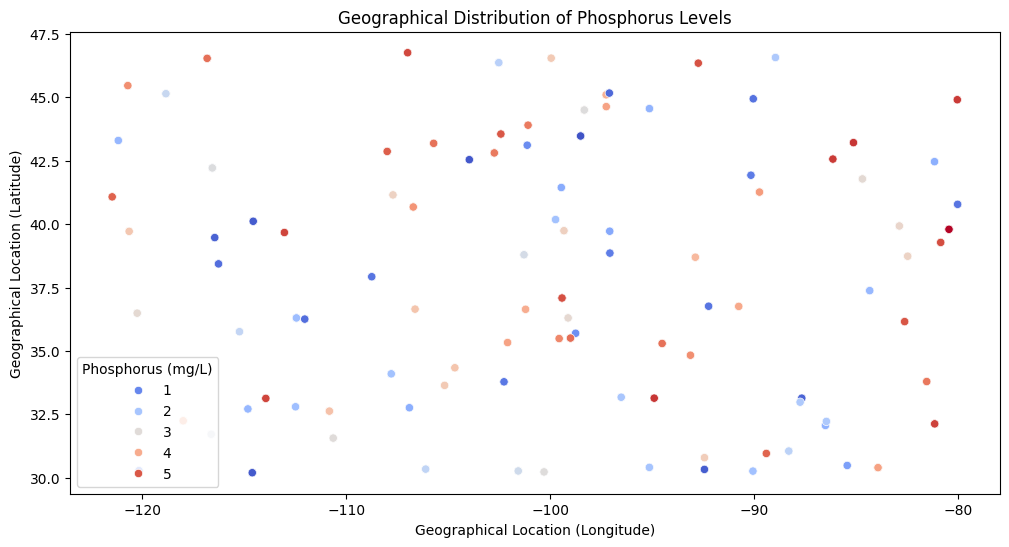

In [8]:
print("4. feladat C,")
plot.figure(figsize=(12,6))
seaborn.scatterplot(
    data,
    x="Geographical Location (Longitude)",
    y="Geographical Location (Latitude)",
    hue="Phosphorus (mg/L)",
    palette="coolwarm",
    )
plot.title("Geographical Distribution of Phosphorus Levels")
plot.legend(loc="lower left", title="Phosphorus (mg/L)")
plot.show()

In [9]:
print("8. Feladat")
data.rename(columns={
"Geographical Location (Latitude)": "Lati",
"Geographical Location (Longitude)": "Long",
"Sampling Date": "SDate",
"Nitrogen (mg/L)": "N",
"Phosphorus (mg/L)": "P",
"State of Sewage System": "SWS"
}, inplace="True")

data.info()


8. Feladat
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Lati        412 non-null    float64       
 1   Long        412 non-null    float64       
 2   SWS         412 non-null    object        
 3   SDate       412 non-null    datetime64[ns]
 4   N           412 non-null    float64       
 5   P           412 non-null    float64       
 6   Population  412 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 22.7+ KB


In [10]:
print("5. feladat")
from matplotlib import colors
max_N = round(data['N'].max())
print(max_N)
levels = range(max_N+1)
color_dict = dict(zip(levels, list(colors.cnames.values())[0:-1:10]))

map_center = [data['Lati'].mean(), data['Long'].mean()]
map = google_maps.Map(location=map_center, zoom_start=3.5)

for __, row in data.iterrows():
    levelNIGGGGGG = round(row["N"])
    color = color_dict.get(levelNIGGGGGG)

    google_maps.CircleMarker(
        location=[row["Lati"], row["Long"]],
        radius=4,
        color=color,
        fill=True,
        fill_color=color
    ).add_to(map)
map


5. feladat
10


6.feladat


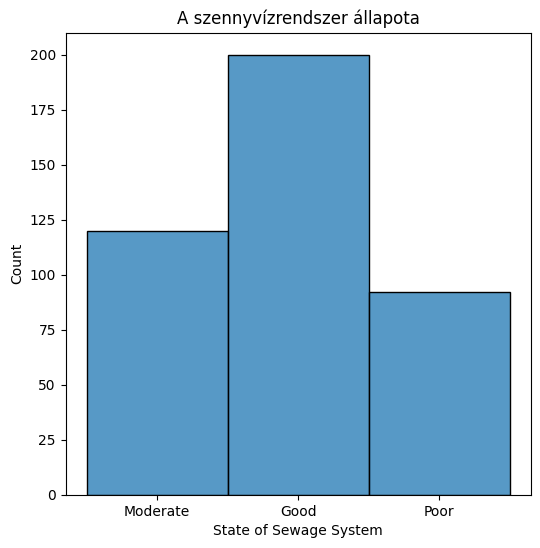

In [11]:
print("6.feladat")
plot.figure(figsize=(6,6))
seaborn.histplot(data["SWS"])
plot.title("A szennyvízrendszer állapota")
plot.ylabel("Count")
plot.xlabel("State of Sewage System")
plot.show()

In [12]:
print("7.feladat A,")

data["N+P"] = data["N"] + data["P"]

data.info()

7.feladat A,
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Lati        412 non-null    float64       
 1   Long        412 non-null    float64       
 2   SWS         412 non-null    object        
 3   SDate       412 non-null    datetime64[ns]
 4   N           412 non-null    float64       
 5   P           412 non-null    float64       
 6   Population  412 non-null    int64         
 7   N+P         412 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 25.9+ KB


In [13]:
from sklearn.calibration import LabelEncoder


print("7. feladat B,")

data["SWS_Numbers"] = LabelEncoder().fit_transform(data["SWS"])

data[["SWS", "SWS_Numbers"]].head()


7. feladat B,


,SWS,SWS_Numbers
0,Moderate,1
1,Good,0
2,Moderate,1
3,Poor,2
4,Moderate,1


In [14]:
print("7. feladat C,")

data_Numeric = data[["Lati", "Long", "N", "P", "Population", "N+P"]]

correlation_Matrix = data_Numeric.corr(method="pearson")
correlation_Matrix

7. feladat C,


,Lati,Long,N,P,Population,N+P
Lati,1.000000,-0.026431,0.098404,0.136975,0.125905,0.144005
Long,-0.026431,1.000000,0.038998,0.111169,0.074368,0.081572
N,0.098404,0.038998,1.000000,0.091690,0.880114,0.903346
P,0.136975,0.111169,0.091690,1.000000,0.474702,0.509933
Population,0.125905,0.074368,0.880114,0.474702,1.000000,0.964755
N+P,0.144005,0.081572,0.903346,0.509933,0.964755,1.000000


7. feladat D,


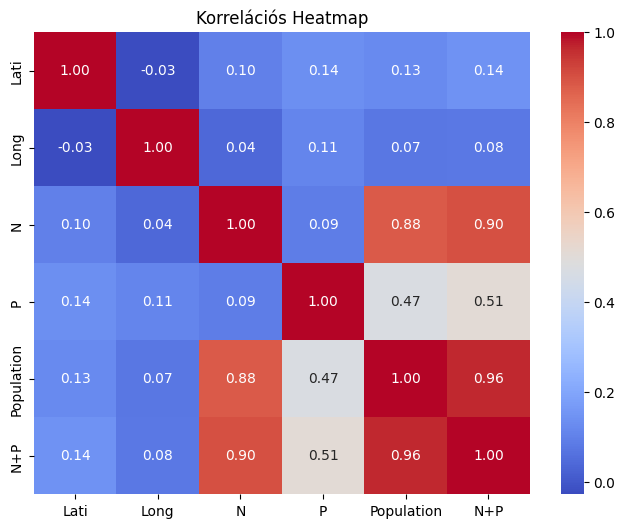

In [15]:
print("7. feladat D,")

plot.figure(figsize=(8,6))
seaborn.heatmap(
    correlation_Matrix,
    annot=True, #Kor megjel
    fmt=".2f", #tizedes
    cmap="coolwarm",
    )
plot.title("Korrelációs Heatmap")
plot.show()

In [16]:
print("9. feladt")
data.describe()

9. feladt


,Lati,Long,SDate,N,P,Population,N+P,SWS_Numbers
count,412.000000,412.000000,412,412.000000,412.000000,4.120000e+02,412.000000,412.000000
mean,37.928978,-99.910523,2019-02-16 10:08:09.320388352,4.956458,2.941068,9.041799e+05,7.897526,0.737864
min,30.198108,-121.476341,2014-01-02 00:00:00,0.004284,0.272931,2.053480e+05,0.379070,0.000000
25%,33.138387,-107.997678,2016-12-24 18:00:00,2.096088,1.593510,6.752212e+05,4.725642,0.000000
50%,37.926803,-99.464055,2018-12-08 12:00:00,4.821583,2.951642,8.774995e+05,7.935702,1.000000
75%,42.542049,-90.071769,2021-07-02 06:00:00,7.575510,4.327313,1.184369e+06,10.852442,1.000000
max,46.759853,-80.039258,2023-12-25 00:00:00,10.294660,5.586694,1.544160e+06,15.538928,2.000000
std,5.088459,11.689830,NaN,3.097449,1.544422,3.163950e+05,3.585622,0.800987


In [17]:
print("10.feladat")

def quality(value):
    if value < 4:
        return 1
    elif value > 10:
        return 3
    else:
        return 2
    
data["Quality"] = data["N+P"].apply(quality)

data["Quality"].head(9)

10.feladat


0    3
1    3
2    2
3    2
4    2
5    3
6    3
7    2
8    1
Name: Quality, dtype: int64

In [18]:
print("11. feladat")

print(data["Quality"].value_counts())


11. feladat
Quality
2    193
3    142
1     77
Name: count, dtype: int64


12. feladat


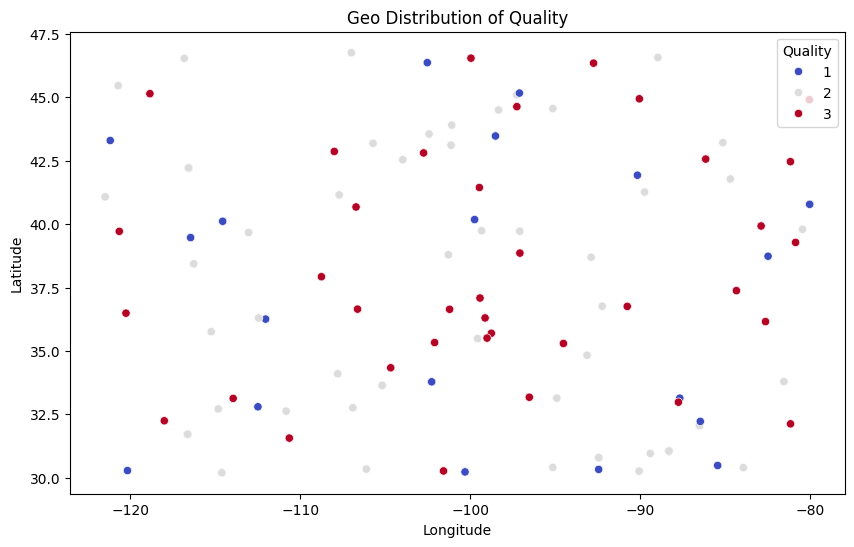

In [19]:
print("12. feladat")

plot.figure(figsize=(10,6))

seaborn.scatterplot(
    data,
    palette="coolwarm",
    x="Long",
    y="Lati",
    hue="Quality"
)
plot.title("Geo Distribution of Quality")
plot.xlabel("Longitude")
plot.ylabel("Latitude")
plot.show()

In [20]:
print("13.feladat")
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

new_Data = data.drop(columns=["SDate"])
new_Data.info()

y = new_Data["SWS"]
x = new_Data.drop(columns=["SWS"])

13.feladat
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Lati         412 non-null    float64
 1   Long         412 non-null    float64
 2   SWS          412 non-null    object 
 3   N            412 non-null    float64
 4   P            412 non-null    float64
 5   Population   412 non-null    int64  
 6   N+P          412 non-null    float64
 7   SWS_Numbers  412 non-null    int64  
 8   Quality      412 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 29.1+ KB


14.feladat


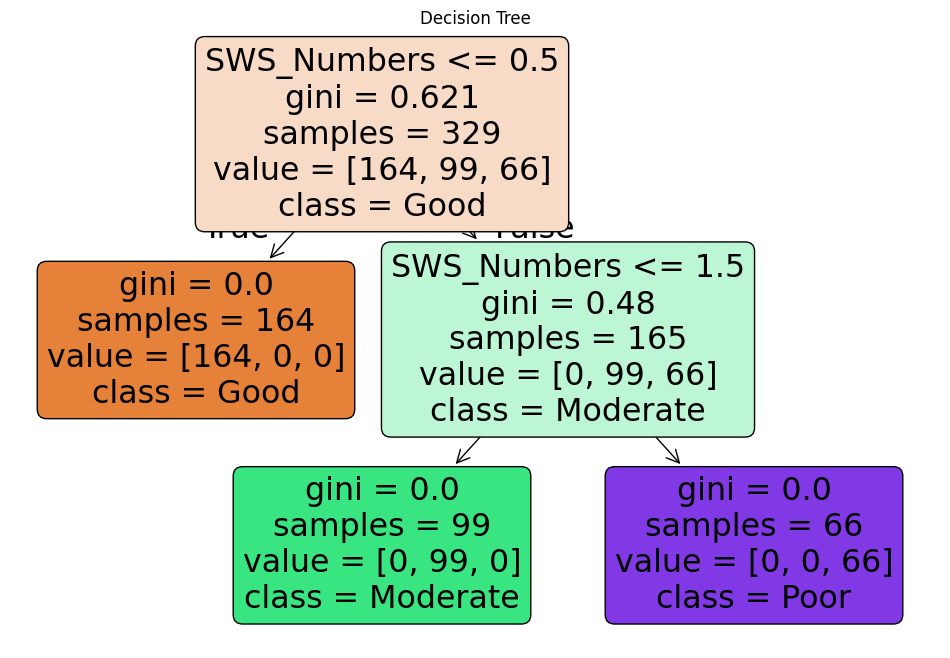

In [21]:
print("14.feladat")

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

plot.figure(figsize=(12, 8))
plot_tree(dt_model, 
          filled=True, 
          rounded=True, 
          class_names=dt_model.classes_, 
          feature_names=x.columns if hasattr(x, 'columns') else None)
plot.title('Decision Tree')
plot.show()

15.feladat
The accuracy of our model is: 1.0000
Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        36
    Moderate       1.00      1.00      1.00        21
        Poor       1.00      1.00      1.00        26

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83



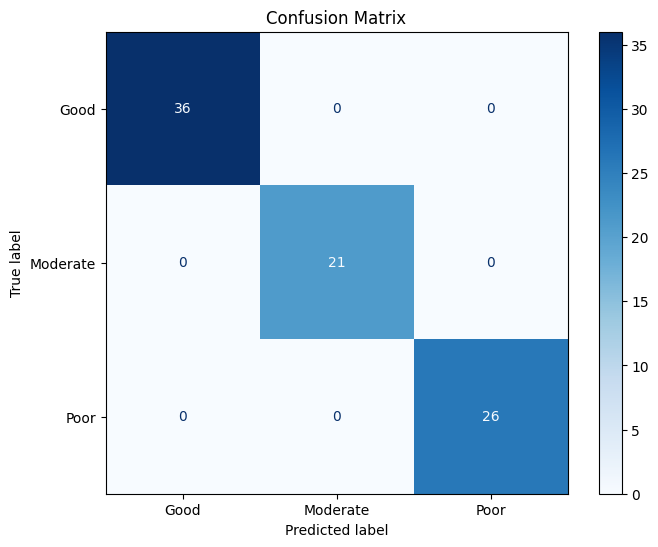

In [25]:
print("15.feladat")
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = dt_model.predict(x_test)

acc = accuracy_score(y_test, y_pred)
print(f"The accuracy of our model is: {acc:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_)

plot.figure(figsize=(8, 6))
disp.plot(cmap='Blues', ax=plot.gca())
plot.title("Confusion Matrix")
plot.show()
